# Laboratorio 2 - Mineria de datos
Fabian Prado # 23427 
Jonathan Zacarías # 231104 
Sofia López # 231929

### Imports

In [59]:
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.discriminant_analysis import StandardScaler

## Cluster

### Data Loading

In [52]:
df_movies = pd.read_csv('movies_2026.csv', encoding='utf-8', encoding_errors='ignore')

In [53]:
df_movies.head()

,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,1626808,0.0,Thriller|Mystery|Documentary,NaN,NaN,NaN,NaN,0.0,5,False,...,2026-02-01,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,1626678,0.0,Animation,NaN,NaN,NaN,NaN,0.0,12,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0


Para la clusterizacion, eliminaremos variables que no aporten un valor numerico, y representen informacion de identificador. Las variables de este tipo son:
id, genres, homePage, productionCompany, productionCompanyCountry, productionCountry, director, releaseDate, actors, actorsCharacter, originalTitle, title, originalLanguage

Por otro lado, las variables que usaremos son:
budget, revenue, runtime, video, actorsPopularity_mean, popularity, voteAvg, voteCount, genresAmount, productionCoAmount, productionCountriesAmount, actorsAmount, castWomenAmount, castMenAmount, releaseYear

### Data Processing

In [54]:
# Funcion para calcular la media de popularidad de los actores
def parse_actor_popularity_mean(popularity_str):
    try:
        values = [float(x) for x in str(popularity_str).split('|') if x.strip() != '']
        return np.mean(values) if values else np.nan
    except:
        return np.nan

In [55]:
# Agregar la nueva columna con la media de popularidad de los actores
df_movies['actorsPopularity_mean'] = df_movies['actorsPopularity'].apply(parse_actor_popularity_mean)

# Seleccionar las variables para el clustering
clustering_vars = [
    'budget', 'revenue', 'runtime', 'video',
    'actorsPopularity_mean', 'popularity', 'voteAvg', 'voteCount',
    'genresAmount', 'productionCoAmount', 'productionCountriesAmount',
    'actorsAmount', 'castWomenAmount', 'castMenAmount', 'releaseYear'
]

df_cluster = df_movies[clustering_vars].copy()

# Limpiar variables y manejar valores faltantes
df_cluster['video'] = df_cluster['video'].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)

df_cluster['budget']  = df_cluster['budget'].replace(0, np.nan)
df_cluster['revenue'] = df_cluster['revenue'].replace(0, np.nan)

df_cluster.fillna(df_cluster.median(numeric_only=True), inplace=True)

# Escalar las variables para el clustering usando z-score
scaler = StandardScaler()
df_cluster_scaled = pd.DataFrame(
    scaler.fit_transform(df_cluster),
    columns=clustering_vars
)

df_cluster_scaled.head()

,budget,revenue,runtime,video,actorsPopularity_mean,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,-0.212781,-0.174703,0.577111,-0.065136,-0.844347,-0.167965,-1.12934,-0.348749,0.040397,-0.853168,-0.548084,-0.040680,-0.073506,-0.114872,0.714519
1,-0.212781,-0.174703,-1.259664,-0.065136,-0.960704,-0.167965,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040832,-0.073548,-0.114943,0.714519
2,-0.212781,-0.174703,-1.279629,-0.065136,-0.957748,-0.168056,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040870,-0.073548,-0.114943,0.714519
3,-0.212781,-0.174703,-1.219734,-0.065136,-0.961260,-0.167919,-1.12934,-0.348749,0.836453,-0.853168,-0.548084,-0.040718,-0.073548,-0.114943,0.714519
4,-0.212781,-0.174703,-1.079980,-0.065136,-0.958500,-0.167951,-1.12934,-0.348749,-0.755659,-0.853168,-0.548084,-0.040870,-0.073548,-0.114943,0.714519


### Hopkings y la VAT 

Por el tamaño del Dataset, no estaremos usando VAT, ya que la matrix resultante no seria legible y no es tan poderoso el analisis en un sample de la data; por otro lado, usaremos un sample del ~10% para Hopkins (2000)

In [56]:
def hopkins_test(X, sample_ratio=0.10):
    data = np.array(X)
    n_samples, n_features = data.shape
    sample_size = int(sample_ratio * n_samples)
    
    neighbors = NearestNeighbors(n_neighbors=2).fit(data)
    
    # Distancia de puntos reales a su vecino más cercano
    random_idx = random.sample(range(n_samples), sample_size)
    real_sample = data[random_idx]
    real_distances, _ = neighbors.kneighbors(real_sample, n_neighbors=2)
    real_distances = real_distances[:, 1]  # no consideramos la distancia a sí mismo
    
    # Distancia de puntos sintéticos a su vecino más cercano
    min_vals = data.min(axis=0)
    max_vals = data.max(axis=0)
    synthetic_sample = np.random.uniform(low=min_vals, high=max_vals, size=(sample_size, n_features))
    synthetic_distances, _ = neighbors.kneighbors(synthetic_sample, n_neighbors=1)
    synthetic_distances = synthetic_distances[:, 0]
    
    hopkins = synthetic_distances.sum() / (synthetic_distances.sum() + real_distances.sum())
    
    return hopkins

In [57]:
H = hopkins_test(df_cluster_scaled)
print(f"Hopkins Statistic: {H:.4f}")
if H > 0.75:
    print("> Strong clustering tendency.")
elif H > 0.5:
    print("> Moderate clustering tendency.")
else:
    print("> Data does not show strong clustering tendency.")

Hopkins Statistic: 0.9916
> Strong clustering tendency.


Ya que nuestro Estadistica de Hopkins es 0.9915 vemos que nuestro dataset si tiene tendencia a ser clusterizado.

### Elbow Graph

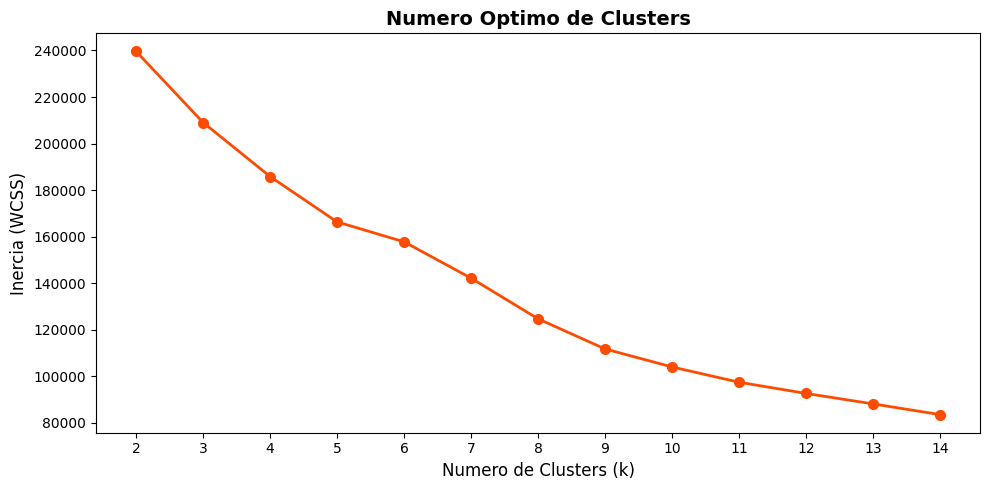

In [58]:
inertia_values = []
k_range = range(2, 15)

import warnings

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)  # hides overflow/div0/invalid warnings
        kmeans.fit(df_cluster_scaled)
    inertia_values.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, inertia_values, marker='o', color='#FC4C02', linewidth=2, markersize=7)
ax.set_xlabel('Numero de Clusters (k)', fontsize=12)
ax.set_ylabel('Inercia (WCSS)', fontsize=12)
ax.set_title('Numero Optimo de Clusters', fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.grid(False) # odio el grid

plt.tight_layout()
plt.show()

Usaremos **5 clusters**

### Si